In [30]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [31]:
!pip3 install tslearn

In [32]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

## Load in Data

In [33]:
# start from the sampled dataframe
all_samples = pd.read_csv('/content/gdrive/MyDrive/Next_Step/400_step_samples_forAll.csv')


In [34]:
# remove all the unneccesary columns
all_samples = all_samples.drop(columns=['Unnamed: 0',' Latitude', ' SampleTimeFine' , ' Longitude',' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z'])

In [35]:
all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)

<ipython-input-35-4c1cbb6f442e>:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)


In [36]:
# making sure all sensors have equal classes
all_samples["sensor_place"].value_counts()

,count
sensor_place,
93,684000
8B,684000
9B,684000
B6,684000
95,684000
CC,684000


In [37]:
# remove the calibration data points and the banked R/L to evaluate model performance
# without these variables because in our data collection they wont be included
all_samples = all_samples.drop(all_samples[all_samples["trial_label"] == 'calibration'].index)

In [38]:
# making sure all surface types have equal classes
all_samples["trial_label"].value_counts()

,count
trial_label,
GR,432000
BNKR,432000
BNKL,432000
SLPD,432000
SLPU,432000
STD,432000
STU,432000
CS,432000
FE,432000


In [39]:
all_samples = all_samples.sort_values(by=['participant_num', 'trial_num', 'og_df_order'])

In [40]:
# seperating inputs by the sensor placement
all_samples_93 = all_samples.loc[all_samples['sensor_place'] == "B6"] # left shank

In [41]:
# list of all of the separated dfs
sensor_dfs = [all_samples_93]

In [42]:
all_sensor_metrics = []
all_sensor_non_metrics = []

for df in sensor_dfs:
    sensor_df_metrics = []
    metrics = pd.DataFrame(df, columns=[' Acc_X', ' Acc_Y',' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z', ' Gyr_X', ' Gyr_Y',
                                                            ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X', ' VelInc_Y',
                                                            ' VelInc_Z', ' Yaw', ' Pitch', ' Roll'])

    # normalize
    metrics = MinMaxScaler().fit_transform(metrics)
    # reshaping numpy array to the correct format (number of sequences, sequence length, number of features)
    numpy_metrics = metrics
    reshape_metrics = np.reshape(numpy_metrics, (1620, 400, 18))
    sensor_df_metrics.append(reshape_metrics)
    all_sensor_metrics.append(sensor_df_metrics)


    # dataframe of the non measurements
    non_metrics = df[['participant_num', 'trial_num', 'trial_label']].copy()
    # reducing the trial label column down to just 1 label per sequence
    drop_doop = non_metrics.drop_duplicates()
    # one hot encode the surface labels (outcome labels)
    label_encoder = LabelEncoder()
    integer_encoded_labels = label_encoder.fit_transform(drop_doop['trial_label'])
    one_hot_encoded_labels = to_categorical(integer_encoded_labels)
    # make encoded variable into numpy
    numpy_result = np.array(one_hot_encoded_labels)
    reshape_non_metrics = np.reshape(numpy_result, (1620, 9))
    all_sensor_non_metrics.append(reshape_non_metrics)


In [43]:
len(all_sensor_metrics)

1

## Setting up X and Y train/test

In [44]:
X_93 = np.array(all_sensor_metrics[0])
Y_93 = np.array(all_sensor_non_metrics[0])

index_split = list(range(1620))
# train, test = train_test_split(index_split, test_size=0.15)

X_93 = X_93.squeeze()

In [45]:
# check variables
n_obs, n_timesteps, n_features, n_classes = 1377, 400, 18, 9

In [46]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional

# # clears the session for tensorflow
# tf.keras.backend.clear_session()

# # Define input shape
# input_shape = (n_timesteps, n_features)
# number_of_inputs = len(all_sensor_metrics)

# # Define 6 parallel branches with different inputs
# branch_models = []
# inputs = []
# branches = []
# labels = []
# count = 0


# input_layer = Input(shape=input_shape)
# inputs.append(input_layer)
# cnn_out = BatchNormalization()(input_layer)
# cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
# cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
# cnn_out = Dropout(0.2)(cnn_out)
# lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)
# attention = Attention()([cnn_out, lstm_out])
# merged = Concatenate(axis=-1)([lstm_out, attention])
# mlp_out = Flatten()(merged)
# mlp_out = Dense(units=128, activation='relu')(mlp_out)
# mlp_out = Dense(units=64, activation='relu')(mlp_out)
# output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)
# model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)

# # Compile the model
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# # Early stopping callback
# callback = EarlyStopping(monitor='loss', patience=8)

# # Train the model
# history = model.fit(x=x_train, y=y_train, validation_data=(x_valid, y_valid), epochs=200, batch_size=128, callbacks=[callback])


# # Print the model summary
# model.summary()


## Hyperparameter tuning

In [47]:
# import numpy as np
# from sklearn.model_selection import train_test_split
# from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional, Concatenate
# from tensorflow.keras.callbacks import EarlyStopping

# num_samples = n_obs
# sequence_length = n_timesteps
# feature_dim = n_features
# num_classes = n_classes

# # Split data into train-validation and test sets
# X_train_val, X_test, y_train_val, y_test = train_test_split(X_93, Y_93, test_size=0.2, random_state=42)

# # Define search space for hyperparameters
# space = {
#     'learning_rate': hp.loguniform('learning_rate', np.log(0.0001), np.log(0.001)),
#     'dropout_rate': hp.uniform('dropout_rate', 0.1, 0.5),
#     'num_units_lstm': hp.choice('num_units_lstm', [32, 64, 128]),
#     'num_filters_cnn': hp.choice('num_filters_cnn', [64, 128, 256]),
# }

# # Define objective function
# def objective(params):
#     # Define the model
#     input_shape = (sequence_length, feature_dim)
#     input_layer = Input(shape=input_shape)
#     cnn_out = BatchNormalization()(input_layer)
#     cnn_out = Conv1D(filters=params['num_filters_cnn'], kernel_size=3, activation='relu')(cnn_out)
#     cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
#     cnn_out = Dropout(params['dropout_rate'])(cnn_out)
#     cnn_out = Dense(units=params['num_units_lstm'], activation='relu')(cnn_out)  # Adjusted
#     lstm_out = Bidirectional(LSTM(units=params['num_units_lstm'], dropout=params['dropout_rate'], recurrent_dropout=params['dropout_rate'], return_sequences=True))(cnn_out)
#     attention = Attention()([lstm_out, lstm_out])  # Adjusted
#     merged = Concatenate(axis=-1)([lstm_out, attention])
#     mlp_out = Flatten()(merged)
#     mlp_out = Dense(units=128, activation='relu')(mlp_out)
#     mlp_out = Dense(units=64, activation='relu')(mlp_out)
#     output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)
#     model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

#     # Compile the model
#     optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#     # Early stopping callback
#     callback = EarlyStopping(monitor='val_loss', patience=10)

#     # Train the model
#     history = model.fit(x=X_train_val, y=y_train_val, validation_split=0.2, epochs=200, batch_size=128, callbacks=[callback])

#     # Evaluate the model on the validation set
#     loss, accuracy = model.evaluate(X_test, y_test)

#     return {'loss': -accuracy, 'status': STATUS_OK}

# # Run Hyperopt optimization
# trials = Trials()
# best = fmin(objective, space, algo=tpe.suggest, max_evals=30, trials=trials)

# print("Best Hyperparameters:", best)


In [48]:
# # Extract best hyperparameters and their corresponding validation accuracy
# best_params = trials.best_trial['misc']['vals']
# best_accuracy = -trials.best_trial['result']['loss']  # Note the negative sign as we minimized the negative validation accuracy

# print("Best Hyperparameters:")
# print("Learning Rate:", best_params['learning_rate'][0])
# print("Dropout Rate:", best_params['dropout_rate'][0])
# print("Number of LSTM Units:", [32, 64, 128][best_params['num_units_lstm'][0]])
# print("Number of CNN Filters:", [64, 128, 256][best_params['num_filters_cnn'][0]])
# print("Best Validation Accuracy:", best_accuracy)


## Train Model

In [50]:
# Assuming you have X_93 and Y_93 defined as your training data
X_train, X_test, Y_train, Y_test = train_test_split(X_93, Y_93, test_size=0.15)


n_obs, n_timesteps, n_features, n_classes = X_train.shape[0], X_train.shape[1], X_train.shape[2], Y_train.shape[1]

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# clears the session for tensorflow
tf.keras.backend.clear_session()

# Define input shape
input_shape = (n_timesteps, n_features)

# Define the model
input_layer = Input(shape=input_shape)
cnn_out = BatchNormalization()(input_layer)
cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = Dropout(0.2)(cnn_out)
lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)
attention = Attention()([lstm_out, lstm_out])
merged = Concatenate(axis=-1)([lstm_out, attention])
mlp_out = Flatten()(merged)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)

model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Early stopping callback
callback = EarlyStopping(monitor='loss', patience=10)

# Train the model
history = model.fit(X_train, Y_train, epochs=200, batch_size=128, validation_split=0.15, callbacks=[callback])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, Y_test)
print('Test accuracy:', accuracy)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 400, 18)        │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 400, 18)        │             72 │ input_layer[0][0]      │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 398, 128)       │          7,040 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 199, 128)       │              0 │ conv1d[0][0]           │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 199, 128)       │              0 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 199, 128)       │         98,816 │ dropout[0][0]          │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, 199, 128)       │              0 │ bidirectional[0][0],   │
│                           │                        │                │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 199, 256)       │              0 │ bidirectional[0][0],   │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 50944)          │              0 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │      6,520,960 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 9)              │            585 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 6,635,729 (25.31 MB)

 Trainable params: 6,635,693 (25.31 MB)

 Non-trainable params: 36 (144.00 B)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 503ms/step - accuracy: 0.2461 - loss: 2.0299 - val_accuracy: 0.2367 - val_loss: 2.1088
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 419ms/step - accuracy: 0.4009 - loss: 1.5390 - val_accuracy: 0.1159 - val_loss: 2.0650
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 472ms/step - accuracy: 0.4960 - loss: 1.3547 - val_accuracy: 0.1159 - val_loss: 2.2582
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 430ms/step - accuracy: 0.5438 - loss: 1.2747 - val_accuracy: 0.0966 - val_loss: 2.2712
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 433ms/step - accuracy: 0.5268 - loss: 1.1869 - val_accuracy: 0.0918 - val_loss: 2.5103
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step - accuracy: 0.5806 - loss: 1.1123 - val_accuracy: 0.0966 - val_loss: 2.3084
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 427ms/step - accuracy: 0.6225 - loss: 1.0219 - val_accuracy: 0.0966 - val_loss: 2.4546
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 441ms/step - accuracy: 0.6312 - loss: 0.9553 - val_acc

### 10 fold cross validation, not needed

In [ ]:
# import numpy as np
# from sklearn.model_selection import KFold
# from sklearn.metrics import accuracy_score, confusion_matrix
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional
# from tensorflow.keras.callbacks import EarlyStopping

# num_samples = n_obs
# sequence_length = n_timesteps
# feature_dim = n_features
# num_classes = n_classes

# # Split data into train-validation and test sets
# X_train_val, X_test, y_train_val, y_test = train_test_split(X_93, Y_93, test_size=0.15, random_state=42)

# # Initialize KFold with desired number of folds
# kfold = KFold(n_splits=10, shuffle=True)

# # Initialize lists to store evaluation metrics
# accuracies = []
# conf_matrices = []

# # Perform k-fold cross-validation
# for train_index, test_index in kfold.split(X_train_val):
#     x_train, x_valid = X_train_val[train_index], X_train_val[test_index]
#     y_train, y_valid = y_train_val[train_index], y_train_val[test_index]

#     # clears the session for tensorflow
#     tf.keras.backend.clear_session()

#     # Define input shape
#     input_shape = (sequence_length, feature_dim)

#     # Define the model
#     input_layer = Input(shape=input_shape)
#     cnn_out = BatchNormalization()(input_layer)
#     cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
#     cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
#     cnn_out = Dropout(0.2)(cnn_out)
#     lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)
#     attention = Attention()([lstm_out, lstm_out])
#     merged = Concatenate(axis=-1)([lstm_out, attention])
#     mlp_out = Flatten()(merged)
#     mlp_out = Dense(units=128, activation='relu')(mlp_out)
#     mlp_out = Dense(units=64, activation='relu')(mlp_out)
#     output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)
#     model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

#     # Compile the model
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#     # Early stopping callback
#     callback = EarlyStopping(monitor='loss', patience=8)

#     # Train the model
#     history = model.fit(x=x_train, y=y_train, validation_data=(x_valid, y_valid), epochs=200, batch_size=128, callbacks=[callback])

#     # Make predictions on the validation data
#     fold_predictions = model.predict(x_valid)
#     fold_predictions_labels = np.argmax(fold_predictions, axis=1)
#     y_valids_labels = np.argmax(y_valid, axis=1)

#     # Compute accuracy for this fold
#     accuracy = accuracy_score(y_valids_labels, fold_predictions_labels)
#     accuracies.append(accuracy)

#     # Compute confusion matrix for this fold
#     conf_matrix = confusion_matrix(y_valids_labels, fold_predictions_labels)
#     conf_matrices.append(conf_matrix)

# # Calculate average accuracy across all folds
# avg_accuracy = sum(accuracies) / len(accuracies)
# print("Average Validation Accuracy:", avg_accuracy)

# # Print confusion matrices for each fold
# for i, conf_matrix in enumerate(conf_matrices):
#     print("Confusion Matrix - Fold", i+1, ":\n", conf_matrix)

# # Evaluate the model on the test set
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print("Test Loss:", test_loss)
# print("Test Accuracy:", test_accuracy)


## Model performance graphs

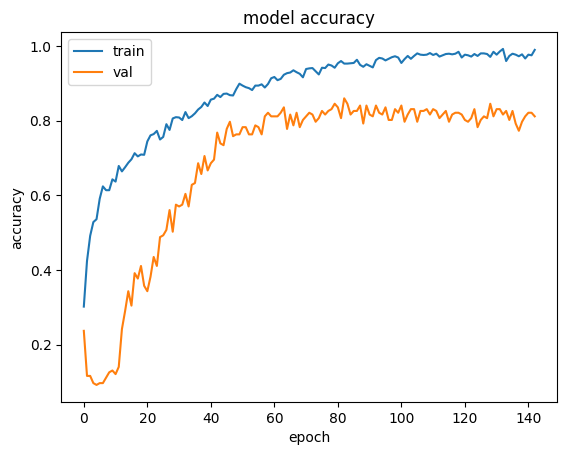

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

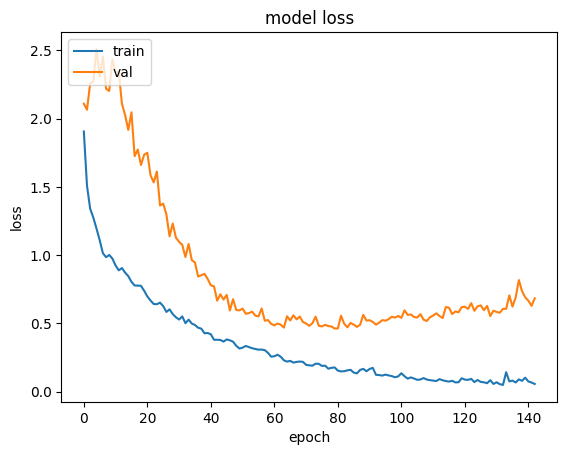

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [54]:
# Get the weights of the individual branch models
branch_weights = []

for branch_model in branch_models:
    branch_weights.append(branch_model.get_weights())

# # Print the weights for each branch
# for i, branch_weight in enumerate(branch_weights):
#     print(f"Weights for Branch {i + 1}:", branch_weight)

In [55]:
# Get the weights of the main model
main_model_weights = model.get_weights()

# # Print the weights for each layer
# for layer_weights in main_model_weights:
#     print(layer_weights)

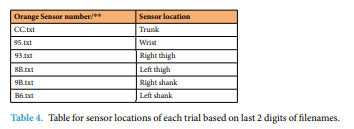

## Confusion Matrix

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# input_data = np.array(x_trains)

print("Evaluate on test data")
results = model.evaluate(X_test, Y_test, batch_size=128)
print("test loss, test acc:", results)


# # Generate predictions (probabilities -- the output of the last layer)
# # on new data using `predict`
# print("Generate predictions for 3 samples")
# predictions = model.predict(fft_x_tests, verbose=0)[:100]
# print("predictions shape:", predictions.shape)


#Predict
y_prediction = model.predict(X_test)

#Create confusion matrix and normalizes it over predicted (columns)
y_prediction = np.argmax(y_prediction, axis=1)
print(y_prediction)
Y_9B_test_proc = np.argmax(Y_test, axis=1)
print(Y_9B_test_proc)
result = confusion_matrix(Y_9B_test_proc, y_prediction , normalize='pred')

# Compute F1 score
f1 = f1_score(Y_9B_test_proc, y_prediction, average='weighted')

print("F1 score:", f1)

Evaluate on test data
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7545 - loss: 0.9558
test loss, test acc: [1.0196099281311035, 0.748971164226532]
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
[0 1 6 8 2 2 2 2 2 0 4 6 1 7 4 8 6 5 7 0 6 7 8 1 8 1 0 1 5 5 7 5 4 6 5 6 1
 1 4 4 0 1 4 1 4 2 7 4 7 7 1 4 5 0 1 7 0 6 6 5 5 0 1 0 2 2 2 2 1 3 3 7 0 0
 5 7 1 3 3 4 6 0 8 1 1 5 5 5 5 3 2 8 5 8 7 7 8 4 7 6 5 2 6 0 0 0 2 2 2 3 0
 6 6 6 3 8 8 6 2 3 4 6 1 8 1 4 8 7 7 7 0 6 1 1 7 8 0 3 7 2 2 7 1 0 8 6 4 5
 0 4 0 1 7 8 1 8 6 1 1 5 1 6 2 2 0 2 0 7 1 6 3 2 0 0 4 1 8 0 1 3 8 3 2 6 8
 0 0 4 2 6 5 3 0 4 3 0 3 1 7 0 3 5 0 2 6 7 3 1 7 7 3 0 1 1 2 5 1 3 3 1 8 7
 5 7 3 1 1 3 3 8 3 6 0 1 2 7 0 2 1 2 1 0 4]
[3 1 6 8 2 2 2 2 2 2 4 6 4 5 4 8 6 7 7 0 6 7 8 1 8 1 0 4 5 3 7 7 4 6 5 6 4
 1 3 3 2 1 3 1 4 2 7 4 3 7 1 4 4 0 1 7 0 3 6 5 7 0 3 0 2 2 2 2 1 2 6 5 2 0
 5 7 1 3 3 4 6 2 8 1 1 5 5 2 5 3 2 8 5 8 7 7 8 4 4 6 2 3 6 0 0 2 2 2 2 3 0
 6 6 6 3 8 8 6 2 1 4 6 1 8 1 5 8 7 5 7 0 6 1 5 7 8 0 3 7 2 2 7 1 3 8 6 4 5
 2 3 0 1 7 

In [57]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

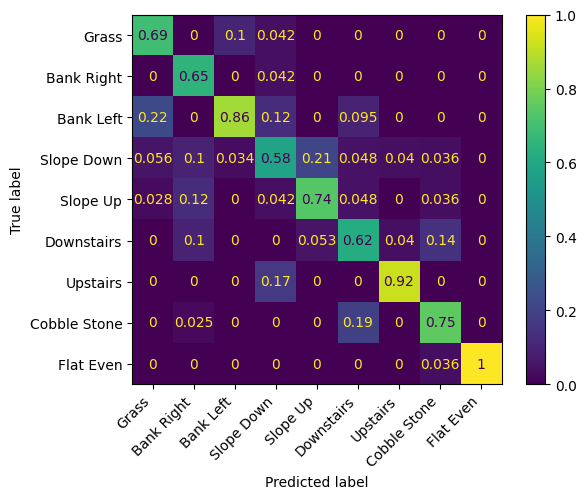

In [58]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['Grass', 'Bank Right', 'Bank Left', 'Slope Down', 'Slope Up', 'Downstairs', 'Upstairs', 'Cobble Stone', 'Flat Even'])

cm_display.plot()
plt.xticks(rotation=45, ha='right')
plt.show()

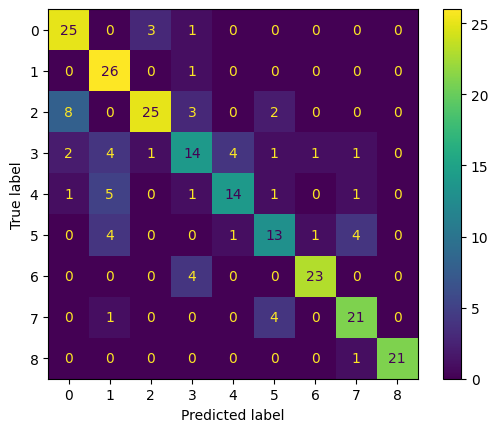

In [59]:
ConfusionMatrixDisplay.from_predictions(Y_9B_test_proc, y_prediction)

In [ ]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE